# Claim-Severity Model Validation

This notebook reviews models for average claim severity conditional on
a policy having complete positive claim information.

The comparison includes:

- a constant weighted-mean severity baseline;
- regularized Gamma regression;
- histogram gradient boosting with Gamma loss.

Policies are weighted by their number of claims because each row
represents a policy-level average over one or more claims.

The preferred model was selected using validation claim-weighted Gamma
deviance.

In [17]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modeling"
    / "claim_severity"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "modeling"
    / "claim_severity"
)

SPLIT_PATH = (
    REPORT_DIR
    / "split_summary.csv"
)

VALIDATION_PATH = (
    REPORT_DIR
    / "validation_severity_model_comparison.csv"
)

TEST_PATH = (
    REPORT_DIR
    / "test_severity_model_comparison.csv"
)

CALIBRATION_PATH = (
    REPORT_DIR
    / "severity_calibration_deciles.csv"
)

SEGMENT_PATH = (
    REPORT_DIR
    / "segment_severity_calibration.csv"
)

COEFFICIENT_PATH = (
    REPORT_DIR
    / "gamma_coefficients.csv"
)

TAIL_PATH = (
    REPORT_DIR
    / "severity_tail_summary.csv"
)

ERROR_PATH = (
    REPORT_DIR
    / "largest_severity_errors.csv"
)

paths = [
    SPLIT_PATH,
    VALIDATION_PATH,
    TEST_PATH,
    CALIBRATION_PATH,
    SEGMENT_PATH,
    COEFFICIENT_PATH,
    TAIL_PATH,
    ERROR_PATH,
]

for path in paths:
    print(
        f"{path.name}: {path.exists()}"
    )

split_summary.csv: True
validation_severity_model_comparison.csv: True
test_severity_model_comparison.csv: True
severity_calibration_deciles.csv: True
segment_severity_calibration.csv: True
gamma_coefficients.csv: True
severity_tail_summary.csv: True
largest_severity_errors.csv: True


In [18]:
split_summary = pd.read_csv(
    SPLIT_PATH
)

validation_results = pd.read_csv(
    VALIDATION_PATH
)

test_results = pd.read_csv(
    TEST_PATH
)

calibration = pd.read_csv(
    CALIBRATION_PATH
)

segment_calibration = pd.read_csv(
    SEGMENT_PATH
)

coefficients = pd.read_csv(
    COEFFICIENT_PATH
)

tail_summary = pd.read_csv(
    TAIL_PATH
)

largest_errors = pd.read_csv(
    ERROR_PATH
)

print("Severity data splits:")
display(split_summary)

print("Validation model comparison:")
display(validation_results)

print("Test model comparison:")
display(test_results)

Severity data splits:


,Sample,Policies,Claims,TotalClaimAmount,WeightedMeanSeverity,MedianPolicyAverageSeverity,MaximumPolicyAverageSeverity
0,Training,14965,15857,"35,964,009.970000","2,268.021061","1,172.000000","4,075,400.560000"
1,Validation,4989,5307,"12,413,833.320000","2,339.143267","1,172.000000","702,092.760000"
2,Test,4989,5279,"11,530,829.880000","2,184.282985","1,172.000000","774,411.500000"


Validation model comparison:


,Model,Sample,WeightedGammaDeviance,D2Gamma,WeightedMAE,WeightedRMSE,WeightedBias,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,PredictedToObservedAmountRatio,ObservedMeanSeverity,PredictedMeanSeverity,MeanSeverityDifference
0,Constant severity baseline,Validation,1.755631,-0.000549,"2,321.867704","16,057.292698",-71.122206,4989,5307,"12,413,833.320000","12,036,387.772642",0.969595,"2,339.143267","2,268.021061",-71.122206
1,Gamma regression,Validation,1.763442,-0.005001,"2,282.080565","16,059.602460",-175.833331,4989,5307,"12,413,833.320000","11,480,685.833029",0.924830,"2,339.143267","2,163.309937",-175.833331
2,Histogram gradient boosting,Validation,1.852579,-0.055801,"1,986.677309","16,073.288464",-562.913293,4989,5307,"12,413,833.320000","9,426,452.476267",0.759351,"2,339.143267","1,776.229975",-562.913293


Test model comparison:


,Model,Sample,WeightedGammaDeviance,D2Gamma,WeightedMAE,WeightedRMSE,WeightedBias,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,PredictedToObservedAmountRatio,ObservedMeanSeverity,PredictedMeanSeverity,MeanSeverityDifference
0,Constant severity baseline,Test,1.647696,-0.000849,"2,172.018237","14,083.720337",83.738076,4989,5279,"11,530,829.880000","11,972,883.182924",1.038337,"2,184.282985","2,268.021061",83.738076
1,Gamma regression,Test,1.822811,-0.107218,"2,149.502548","14,112.936064",13.050227,4989,5279,"11,530,829.880000","11,599,722.028279",1.005975,"2,184.282985","2,197.333212",13.050227
2,Histogram gradient boosting,Test,1.822550,-0.107059,"1,851.891417","14,106.260752",-392.328411,4989,5279,"11,530,829.880000","9,459,728.199798",0.820386,"2,184.282985","1,791.954575",-392.328411


In [19]:
comparison_columns = [
    "Model",
    "WeightedGammaDeviance",
    "D2Gamma",
    "WeightedMAE",
    "WeightedRMSE",
    "WeightedBias",
    "ObservedClaimAmount",
    "PredictedClaimAmount",
    "PredictedToObservedAmountRatio",
    "ObservedMeanSeverity",
    "PredictedMeanSeverity",
]

display(
    test_results[
        comparison_columns
    ].sort_values(
        "WeightedGammaDeviance"
    )
)

,Model,WeightedGammaDeviance,D2Gamma,WeightedMAE,WeightedRMSE,WeightedBias,ObservedClaimAmount,PredictedClaimAmount,PredictedToObservedAmountRatio,ObservedMeanSeverity,PredictedMeanSeverity
0,Constant severity baseline,1.647696,-0.000849,"2,172.018237","14,083.720337",83.738076,"11,530,829.880000","11,972,883.182924",1.038337,"2,184.282985","2,268.021061"
2,Histogram gradient boosting,1.822550,-0.107059,"1,851.891417","14,106.260752",-392.328411,"11,530,829.880000","9,459,728.199798",0.820386,"2,184.282985","1,791.954575"
1,Gamma regression,1.822811,-0.107218,"2,149.502548","14,112.936064",13.050227,"11,530,829.880000","11,599,722.028279",1.005975,"2,184.282985","2,197.333212"


In [20]:
selected_model = (
    validation_results.sort_values(
        [
            "WeightedGammaDeviance",
            "D2Gamma",
        ],
        ascending=[True, False],
    )
    .iloc[0]["Model"]
)

selected_test = test_results.loc[
    test_results["Model"].eq(
        selected_model
    )
].iloc[0]

print(
    "Validation-selected severity model:",
    selected_model,
)

display(
    selected_test.to_frame(
        name="Value"
    )
)

Validation-selected severity model: Constant severity baseline


,Value
Model,Constant severity baseline
Sample,Test
WeightedGammaDeviance,1.647696
D2Gamma,-0.000849
WeightedMAE,"2,172.018237"
WeightedRMSE,"14,083.720337"
WeightedBias,83.738076
Policies,4989
Claims,5279
ObservedClaimAmount,"11,530,829.880000"


In [21]:
print(
    "Observed test claim amount:",
    f"{selected_test['ObservedClaimAmount']:,.2f}",
)

print(
    "Predicted test claim amount:",
    f"{selected_test['PredictedClaimAmount']:,.2f}",
)

print(
    "Predicted-to-observed amount ratio:",
    f"{selected_test['PredictedToObservedAmountRatio']:.4f}",
)

print(
    "Observed mean severity:",
    f"{selected_test['ObservedMeanSeverity']:,.2f}",
)

print(
    "Predicted mean severity:",
    f"{selected_test['PredictedMeanSeverity']:,.2f}",
)

print(
    "Weighted severity bias:",
    f"{selected_test['WeightedBias']:,.2f}",
)

Observed test claim amount: 11,530,829.88
Predicted test claim amount: 11,972,883.18
Predicted-to-observed amount ratio: 1.0383
Observed mean severity: 2,184.28
Predicted mean severity: 2,268.02
Weighted severity bias: 83.74


In [22]:
display(
    calibration[
        [
            "RiskDecile",
            "Policies",
            "Claims",
            "ObservedClaimAmount",
            "PredictedClaimAmount",
            "ObservedSeverity",
            "PredictedSeverity",
            "ObservedToExpectedRatio",
        ]
    ]
)

,RiskDecile,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio
0,1,499,529,"1,004,801.660000","1,199,783.141460","1,899.436030","2,268.021061",0.837486
1,2,499,527,"1,047,300.610000","1,195,247.099337","1,987.287685","2,268.021061",0.876221
2,3,499,525,"1,336,876.730000","1,190,711.057214","2,546.431867","2,268.021061",1.122755
3,4,499,541,"994,899.820000","1,226,999.394196","1,839.001516","2,268.021061",0.810840
4,5,499,524,"1,873,491.990000","1,188,443.036153","3,575.366393","2,268.021061",1.576426
5,6,498,524,"755,858.460000","1,188,443.036153","1,442.477977","2,268.021061",0.636007
6,7,499,530,"1,030,731.160000","1,202,051.162521","1,944.775774","2,268.021061",0.857477
7,8,499,522,"931,844.740000","1,183,906.994030","1,785.143180","2,268.021061",0.787093
8,9,499,535,"1,520,342.530000","1,213,391.267828","2,841.761738","2,268.021061",1.252970
9,10,499,522,"1,034,682.180000","1,183,906.994030","1,982.149770","2,268.021061",0.873956


In [23]:
lowest_decile = (
    calibration.sort_values(
        "RiskDecile"
    )
    .iloc[0]
)

highest_decile = (
    calibration.sort_values(
        "RiskDecile"
    )
    .iloc[-1]
)

severity_separation = (
    highest_decile[
        "ObservedSeverity"
    ]
    / lowest_decile[
        "ObservedSeverity"
    ]
)

print(
    "Lowest-decile observed severity:",
    f"{lowest_decile['ObservedSeverity']:,.2f}",
)

print(
    "Highest-decile observed severity:",
    f"{highest_decile['ObservedSeverity']:,.2f}",
)

print(
    "Highest-to-lowest observed-severity ratio:",
    f"{severity_separation:.2f}",
)

Lowest-decile observed severity: 1,899.44
Highest-decile observed severity: 1,982.15
Highest-to-lowest observed-severity ratio: 1.04


In [24]:
severity_ranking_consistent = (
    highest_decile["ObservedSeverity"]
    > lowest_decile["ObservedSeverity"]
)

print(
    "Observed severity increases from "
    "lowest to highest predicted decile:",
    severity_ranking_consistent,
)

Observed severity increases from lowest to highest predicted decile: True


In [25]:
for segment_type in [
    "Area",
    "VehGas",
    "VehBrand",
    "DrivAgeBand",
    "VehAgeBand",
    "BonusMalusBand",
]:
    print(
        f"Severity calibration by {segment_type}:"
    )

    display(
        segment_calibration.loc[
            segment_calibration[
                "SegmentType"
            ].eq(segment_type)
        ][
            [
                "Segment",
                "Policies",
                "Claims",
                "ObservedClaimAmount",
                "PredictedClaimAmount",
                "ObservedSeverity",
                "PredictedSeverity",
                "ObservedToExpectedRatio",
                "EligibleForComparison",
            ]
        ]
    )

Severity calibration by Area:


,Segment,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio,EligibleForComparison
0,A,617,638,"1,859,538.430000","1,446,997.437148","2,914.637038","2,268.021061",1.285101,True
1,B,513,537,"1,263,560.330000","1,217,927.309951","2,352.998752","2,268.021061",1.037468,True
2,C,1303,1377,"2,513,648.320000","3,123,065.001494","1,825.452665","2,268.021061",0.804866,True
3,D,1240,1314,"2,491,522.190000","2,980,179.674628","1,896.135609","2,268.021061",0.836031,True
4,E,1168,1257,"3,206,851.490000","2,850,902.474131","2,551.194503","2,268.021061",1.124855,True
5,F,148,156,"195,709.120000","353,811.285572","1,254.545641","2,268.021061",0.553145,True


Severity calibration by VehGas:


,Segment,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio,EligibleForComparison
6,'Diesel',2509,2656,"6,240,337.730000","6,023,863.938975","2,349.524748","2,268.021061",1.035936,True
7,'Regular',2480,2623,"5,290,492.150000","5,949,019.243950","2,016.962314","2,268.021061",0.889305,True


Severity calibration by VehBrand:


...

,Segment,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio,EligibleForComparison
19,Under 21,132,144,"288,827.960000","326,595.032836","2,005.749722","2,268.021061",0.884361,True
20,21-24,261,286,"785,025.730000","648,654.023549","2,744.845210","2,268.021061",1.210238,True
21,25-29,421,450,"787,632.560000","1,020,609.477612","1,750.294578","2,268.021061",0.771728,True
22,30-39,1089,1143,"2,400,249.450000","2,592,348.073136","2,099.955774","2,268.021061",0.925898,True
23,40-49,1249,1309,"3,305,942.540000","2,968,839.569321","2,525.548159","2,268.021061",1.113547,True
24,50-59,1022,1088,"2,135,123.550000","2,467,606.914761","1,962.429733","2,268.021061",0.865261,True
25,60-69,466,491,"955,821.970000","1,113,598.341128","1,946.684257","2,268.021061",0.858318,True
26,70-79,256,271,"502,147.150000","614,633.707629","1,852.941513","2,268.021061",0.816986,True
27,80+,93,97,"370,058.970000","219,998.042952","3,815.040928","2,268.021061",1.682101,False


Severity calibration by VehAgeBand:


,Segment,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio,EligibleForComparison
28,0,212,225,"401,782.590000","510,304.738806","1,785.700400","2,268.021061",0.787339,True
29,1-2,877,941,"2,524,626.150000","2,134,207.818741","2,682.918332","2,268.021061",1.182934,True
30,3-5,1023,1083,"2,626,129.570000","2,456,266.809454","2,424.865716","2,268.021061",1.069155,True
31,6-10,1473,1567,"3,477,162.470000","3,553,989.003153","2,218.993280","2,268.021061",0.978383,True
32,11-15,1091,1136,"2,003,567.030000","2,576,471.925706","1,763.703371","2,268.021061",0.777640,True
33,16-20,282,296,"453,860.890000","671,334.234163","1,533.313818","2,268.021061",0.676058,True
34,21+,31,31,"43,701.180000","70,308.652902","1,409.715484","2,268.021061",0.621562,False


Severity calibration by BonusMalusBand:


,Segment,Policies,Claims,ObservedClaimAmount,PredictedClaimAmount,ObservedSeverity,PredictedSeverity,ObservedToExpectedRatio,EligibleForComparison
35,Below 60,2760,2894,"6,064,556.130000","6,563,652.951578","2,095.561897","2,268.021061",0.923961,True
36,60-69,676,718,"1,943,567.810000","1,628,439.122057","2,706.918955","2,268.021061",1.193516,True
37,70-79,413,439,"978,444.040000","995,661.245937","2,228.801913","2,268.021061",0.982708,True
38,80-89,305,319,"653,920.470000","723,498.718574","2,049.907429","2,268.021061",0.903831,True
39,90-99,357,381,"793,787.770000","864,116.024379","2,083.432467","2,268.021061",0.918612,True
40,100-109,299,335,"686,900.290000","759,787.055556","2,050.448627","2,268.021061",0.904069,True
41,110-129,154,165,"362,278.040000","374,223.475125","2,195.624485","2,268.021061",0.968079,True
42,130-149,15,16,"29,947.320000","36,288.336982","1,871.707500","2,268.021061",0.825260,False
43,150+,10,12,"17,428.010000","27,216.252736","1,452.334167","2,268.021061",0.640353,False


In [26]:
positive_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] > 0
    ]
    .sort_values(
        "Coefficient",
        ascending=False,
    )
    .head(15)
)

negative_coefficients = (
    coefficients.loc[
        coefficients["Coefficient"] < 0
    ]
    .sort_values(
        "Coefficient",
        ascending=True,
    )
    .head(15)
)

print("Strongest positive Gamma coefficients:")

display(
    positive_coefficients[
        [
            "Feature",
            "Coefficient",
            "SeverityRatio",
        ]
    ]
)

print("Strongest negative Gamma coefficients:")

display(
    negative_coefficients[
        [
            "Feature",
            "Coefficient",
            "SeverityRatio",
        ]
    ]
)

Strongest positive Gamma coefficients:


,Feature,Coefficient,SeverityRatio
2,categorical__VehBrand_B4,0.366476,1.442642
3,categorical__Region_R22,0.353277,1.423725
4,categorical__Region_R43,0.342505,1.408472
6,categorical__Area_B,0.296850,1.345613
10,categorical__VehBrand_B2,0.279114,1.321958
13,categorical__VehBrand_B10,0.257638,1.293870
14,numeric__LogDensity,0.246941,1.280104
15,categorical__Region_R93,0.237257,1.267767
16,categorical__Region_R25,0.229791,1.258337
17,categorical__Region_R82,0.224694,1.251940


Strongest negative Gamma coefficients:


,Feature,Coefficient,SeverityRatio
0,categorical__Area_F,-0.910501,0.402322
1,categorical__Area_E,-0.688325,0.502417
5,categorical__Region_R83,-0.326892,0.721162
7,categorical__Area_C,-0.286928,0.750566
8,categorical__Area_D,-0.286679,0.750753
9,categorical__Region_R21,-0.282458,0.753928
11,categorical__Region_R42,-0.266186,0.766296
12,categorical__VehBrand_B14,-0.264530,0.767567
18,categorical__Region_R74,-0.218979,0.803339
20,categorical__VehBrand_B5,-0.190926,0.826193


In [27]:
display(tail_summary)

,Metric,Value
0,Policy average severity: Minimum,1.490000
1,Policy average severity: 25th percentile,716.930000
2,Policy average severity: Median,"1,172.000000"
3,Policy average severity: 75th percentile,"1,218.280000"
4,Policy average severity: 90th percentile,"2,735.646000"
5,Policy average severity: 95th percentile,"4,356.261000"
6,Policy average severity: 99th percentile,"17,479.755600"
7,Policy average severity: 99.5th percentile,"37,744.280000"
8,Policy average severity: 99.9th percentile,"186,642.871040"
9,Policy average severity: Maximum,"774,411.500000"


In [28]:
display(
    largest_errors[
        [
            "IDpol",
            "ClaimNb",
            "Area",
            "VehAge",
            "DrivAge",
            "BonusMalus",
            "CompleteTotalClaimAmount",
            "AverageClaimSeverity",
            "PredictedSeverity",
            "AbsoluteFinancialError",
        ]
    ].head(20)
)

,IDpol,ClaimNb,Area,VehAge,DrivAge,BonusMalus,CompleteTotalClaimAmount,AverageClaimSeverity,PredictedSeverity,AbsoluteFinancialError
0,3122016,1,E,7,40,63,"774,411.500000","774,411.500000","2,268.021061","772,143.478939"
1,3025890,2,A,1,36,50,"382,955.140000","191,477.570000","2,268.021061","378,419.097877"
2,158309,1,A,3,46,50,"301,635.490000","301,635.490000","2,268.021061","299,367.468939"
3,3150210,1,D,4,61,54,"281,897.490000","281,897.490000","2,268.021061","279,629.468939"
4,1067220,1,C,14,83,50,"205,432.050000","205,432.050000","2,268.021061","203,164.028939"
5,3196736,1,A,13,33,72,"186,584.150000","186,584.150000","2,268.021061","184,316.128939"
6,53865,1,E,1,23,80,"183,073.660000","183,073.660000","2,268.021061","180,805.638939"
7,5068147,1,E,6,23,100,"125,847.050000","125,847.050000","2,268.021061","123,579.028939"
8,2101212,1,D,7,52,71,"92,149.000000","92,149.000000","2,268.021061","89,880.978939"
9,3097066,1,E,4,47,50,"78,104.830000","78,104.830000","2,268.021061","75,836.808939"


test_gamma_deviance_comparison.png


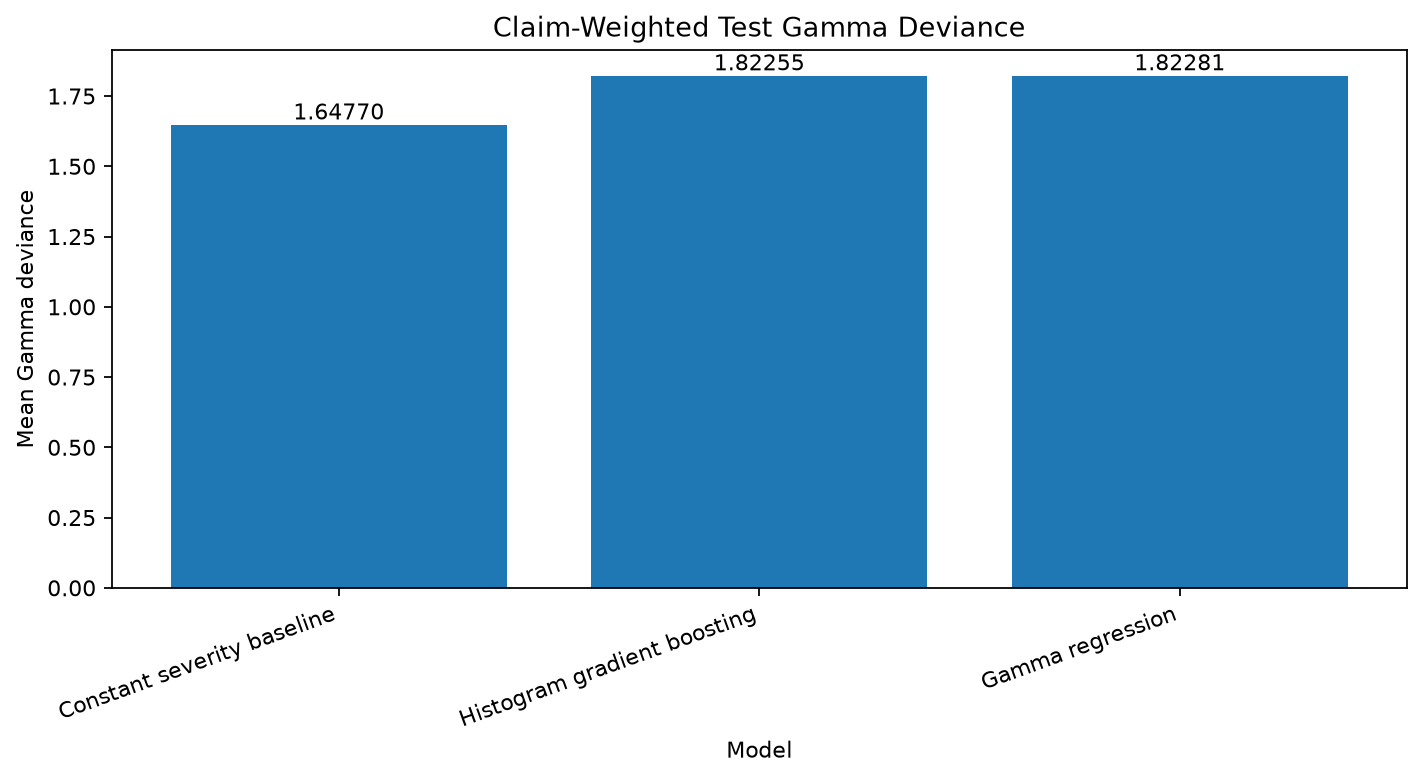

severity_calibration_deciles.png


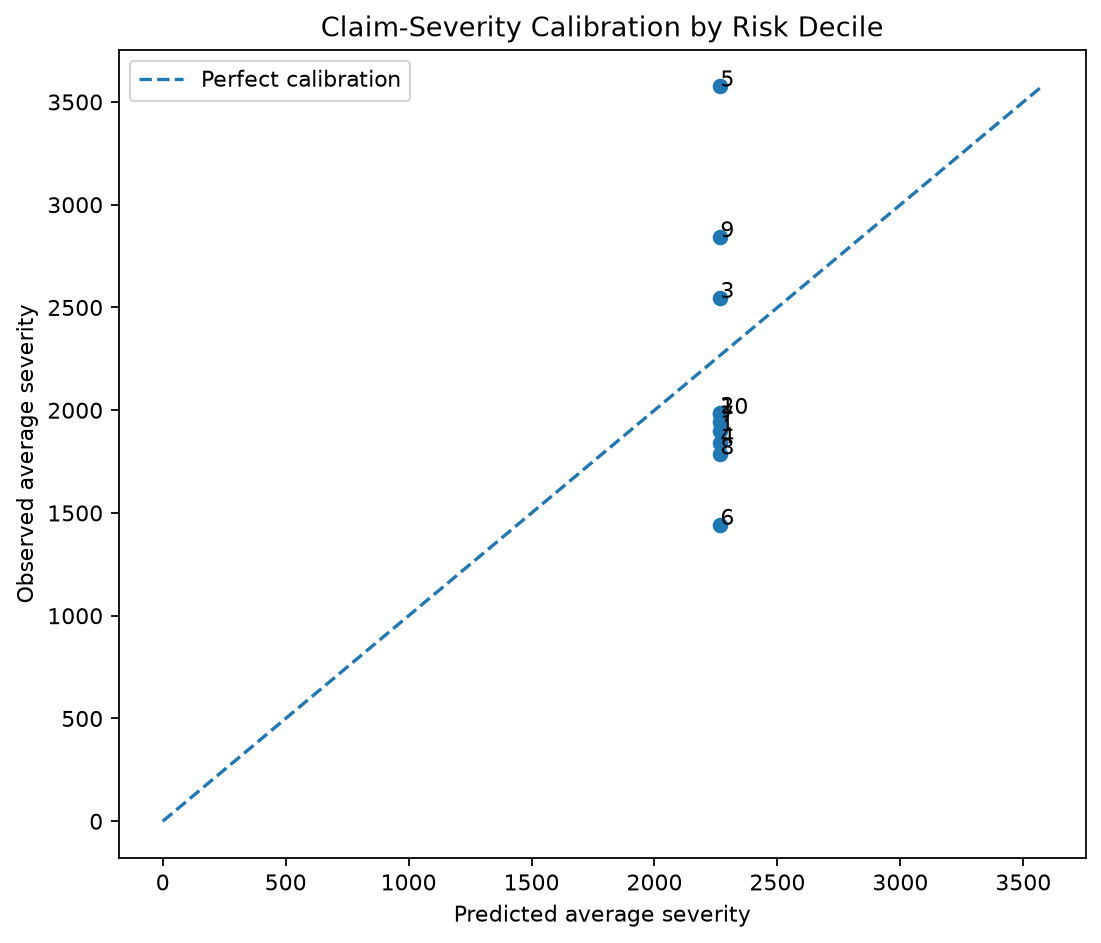

observed_predicted_severity_by_decile.png


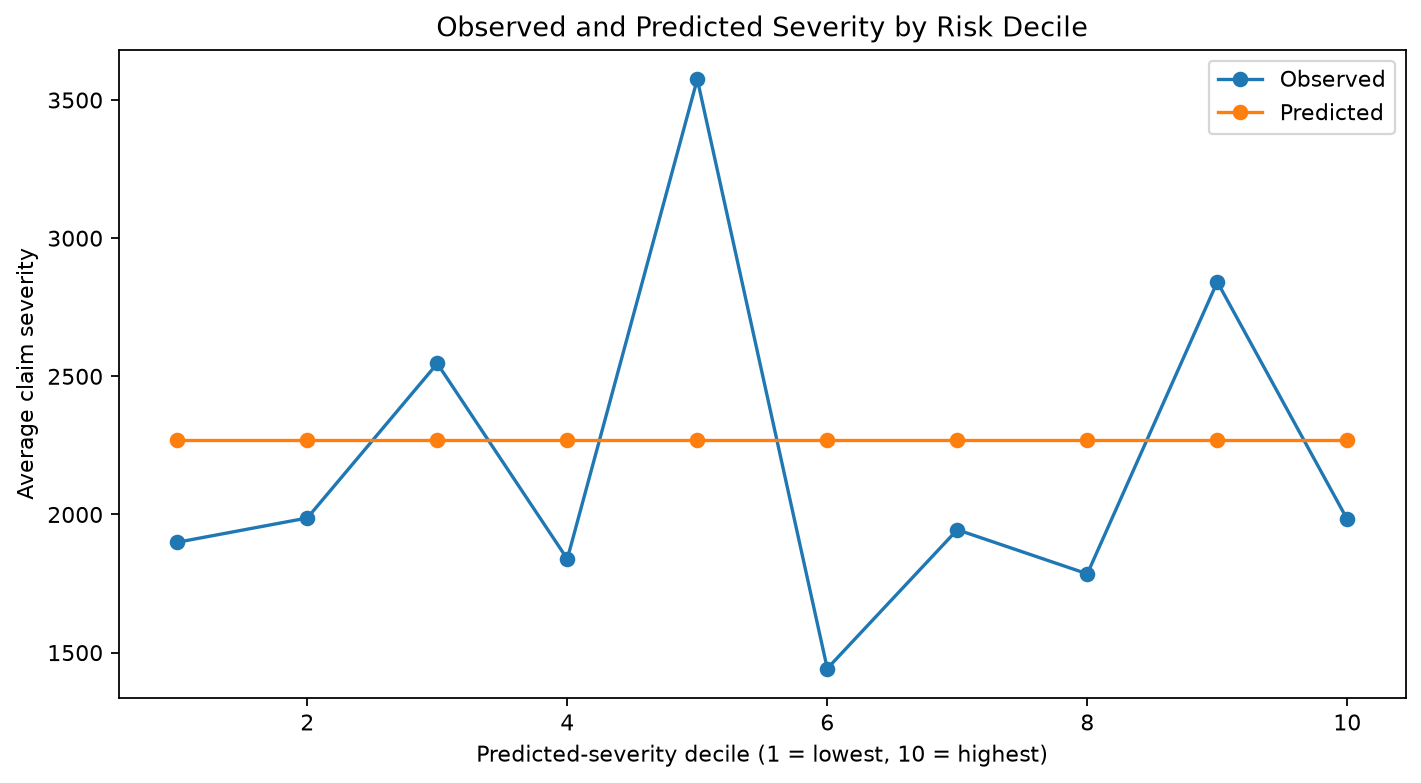

claim_severity_distribution_log.png


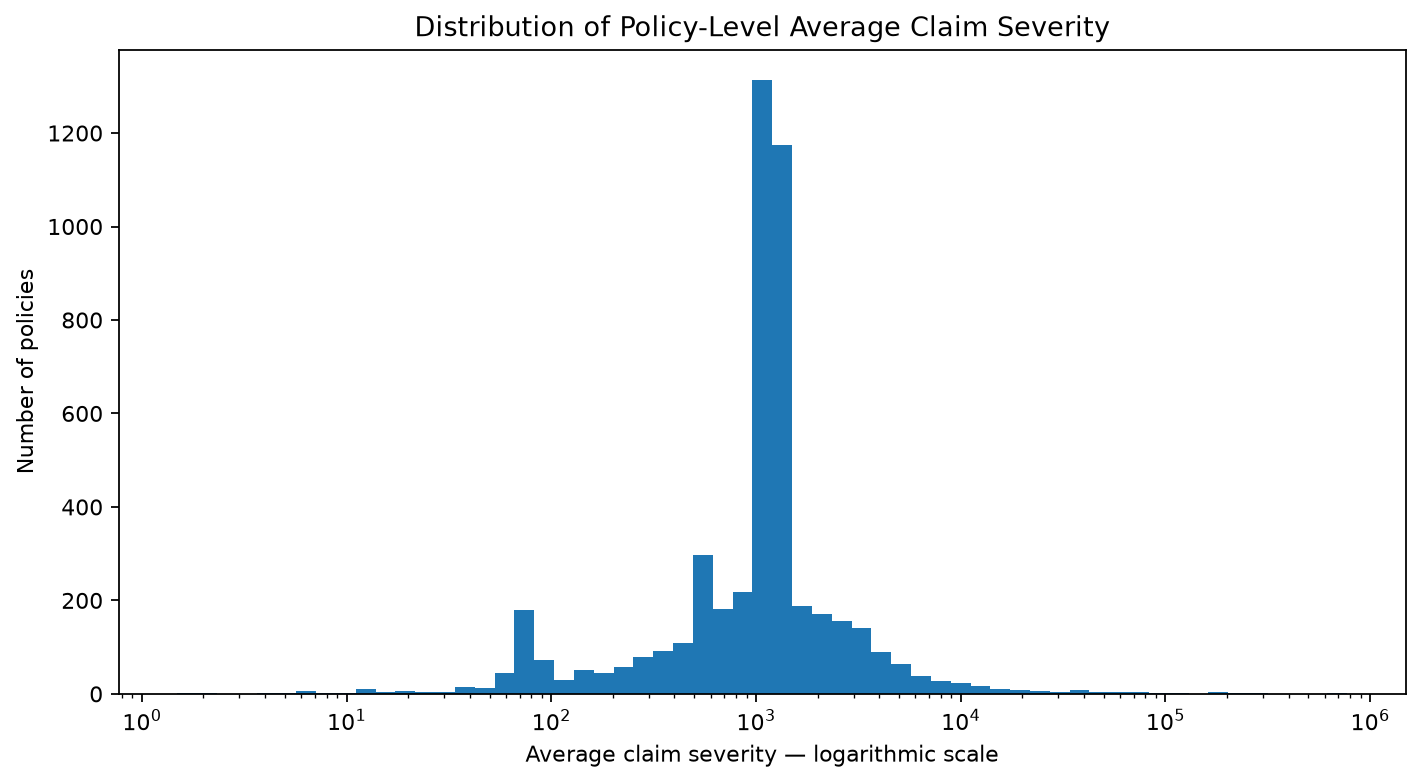

bonus_malus_severity_calibration.png


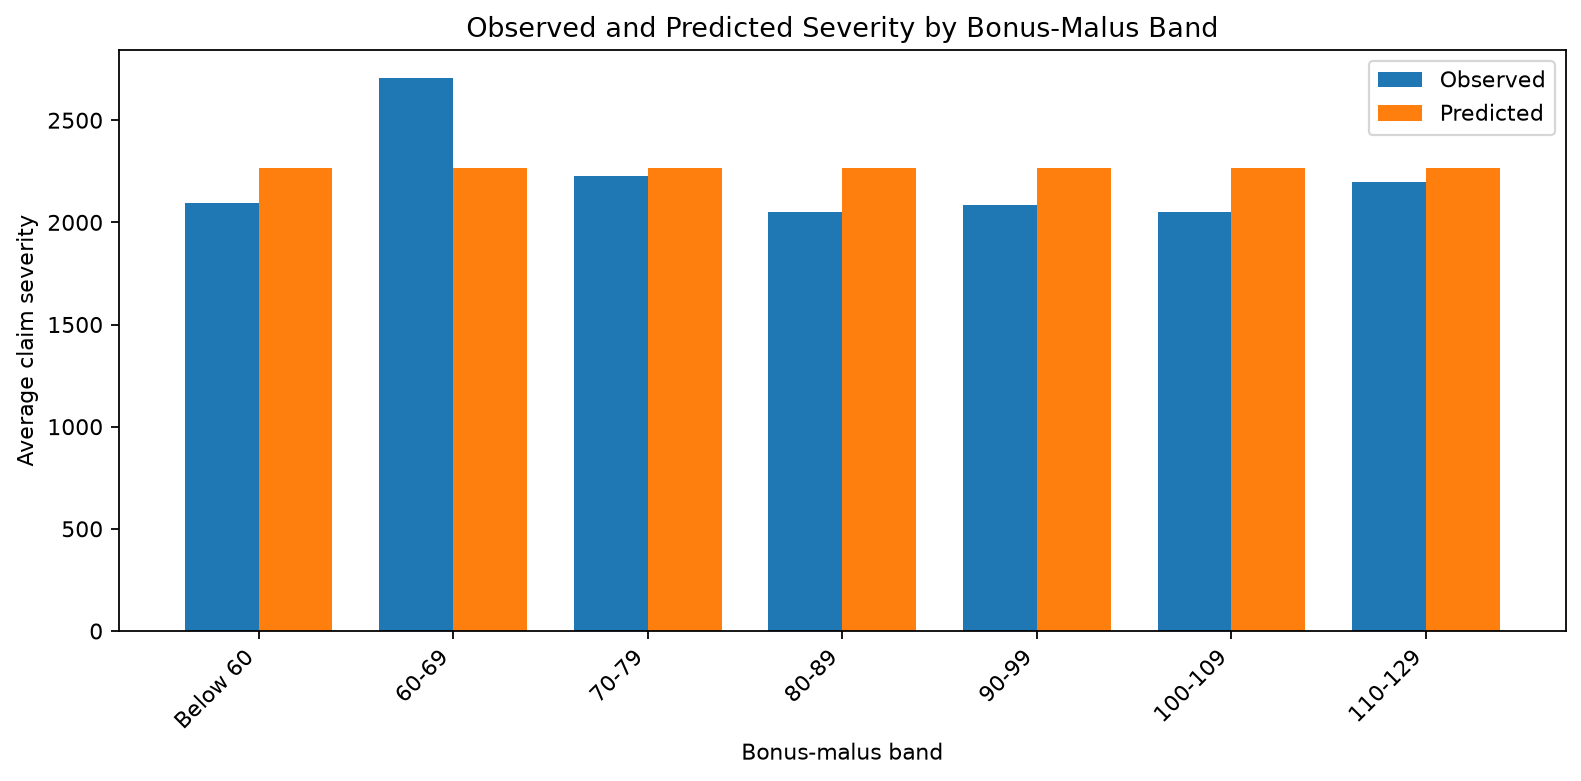

In [29]:
figure_files = [
    "test_gamma_deviance_comparison.png",
    "severity_calibration_deciles.png",
    "observed_predicted_severity_by_decile.png",
    "claim_severity_distribution_log.png",
    "bonus_malus_severity_calibration.png",
]

for filename in figure_files:
    print(filename)

    display(
        Image(
            filename=str(
                FIGURES_DIR
                / filename
            )
        )
    )

In [30]:
checks = pd.DataFrame(
    {
        "Validation": [
            "Three models were evaluated",
            "Selected model came from validation",
            "All Gamma deviances are finite",
            "All predicted claim amounts are positive",
            "Calibration contains ten deciles",
            "Predicted severity is positive in every decile",
            "Segment calibration is non-empty",
            "Gamma coefficient table is non-empty",
            "Tail summary is non-empty",
            "Largest-error report contains records",
        ],
        "Passed": [
            len(test_results) == 3,
            selected_model
            in validation_results[
                "Model"
            ].tolist(),
            test_results[
                "WeightedGammaDeviance"
            ].notna().all(),
            test_results[
                "PredictedClaimAmount"
            ].gt(0).all(),
            calibration[
                "RiskDecile"
            ].nunique() == 10,
            calibration[
                "PredictedSeverity"
            ].gt(0).all(),
            len(segment_calibration) > 0,
            len(coefficients) > 0,
            len(tail_summary) > 0,
            len(largest_errors) > 0,
        ],
    }
)

display(checks)

print(
    "All validation checks passed:",
    checks["Passed"].all(),
)

,Validation,Passed
0,Three models were evaluated,True
1,Selected model came from validation,True
2,All Gamma deviances are finite,True
3,All predicted claim amounts are positive,True
4,Calibration contains ten deciles,True
5,Predicted severity is positive in every decile,True
6,Segment calibration is non-empty,True
7,Gamma coefficient table is non-empty,True
8,Tail summary is non-empty,True
9,Largest-error report contains records,True


All validation checks passed: True
